# Q2 联合搜索与逐参数 Profile 稳定性分析

这份 Notebook 用于检查当前模型是否“稳”。

核心不是固定其他参数只改一个参数，而是：

> 固定一个参数的候选值，其余参数全部重新寻优。

这样同时观察性能稳定性与参数结构稳定性。

**Sep–Dec 独立测试集没有参与本轮搜索。**


In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()

print("当前 Notebook 工作目录：")
print(ROOT)

def find_result_file(*names):
    """在几个常见位置中寻找结果文件。"""
    search_dirs = [
        ROOT,
        ROOT / "results",
        ROOT / "q2_joint_profile_results_v2",
        ROOT.parent / "Robustness",
        ROOT.parent / "results",
    ]

    for directory in search_dirs:
        for name in names:
            path = directory / name
            if path.exists():
                print(f"找到: {path}")
                return path

    searched = [
        str(directory / name)
        for directory in search_dirs
        for name in names
    ]

    raise FileNotFoundError(
        "没有找到所需结果文件。\n"
        "尝试过以下路径：\n"
        + "\n".join(searched)
    )


best_path = find_result_file(
    "global_best_validation.csv",
    "Q2_global_best_validation.csv",
)

byW_path = find_result_file(
    "best_by_W_profile.csv",
    "Q2_best_by_W_profile.csv",
)

prof_path = find_result_file(
    "parameter_profile_results.csv",
    "Q2_parameter_profile_results.csv",
)

stab_path = find_result_file(
    "parameter_stability_summary.csv",
    "Q2_parameter_stability_summary.csv",
)

top_path = find_result_file(
    "top100_joint_configs.csv",
    "Q2_top100_joint_configs.csv",
)


best = pd.read_csv(best_path)
byW = pd.read_csv(byW_path)
prof = pd.read_csv(prof_path)
stab = pd.read_csv(stab_path)
top = pd.read_csv(top_path)

print("\n所有结果文件读取成功。")
display(best)

当前 Notebook 工作目录：
e:\桌面\CUMCM_2026\q2\Robustness
找到: e:\桌面\CUMCM_2026\q2\Robustness\results\Q2_global_best_validation.csv
找到: e:\桌面\CUMCM_2026\q2\Robustness\results\Q2_best_by_W_profile.csv
找到: e:\桌面\CUMCM_2026\q2\Robustness\results\Q2_parameter_profile_results.csv
找到: e:\桌面\CUMCM_2026\q2\Robustness\results\Q2_parameter_stability_summary.csv
找到: e:\桌面\CUMCM_2026\q2\Robustness\results\Q2_top100_joint_configs.csv

所有结果文件读取成功。


,W,load_id,pv_id,val_net_rmse,KL,KP,hL,hP,calL,calP,alphaL,alphaP
0,60,232,172,392.62323,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0


## 1. 联合搜索

超参数向量：

$$
\theta=(W,K_L,K_P,h_L,h_P,C_L,C_P,\alpha_L,\alpha_P).
$$

目标：

$$
\theta^*=\arg\min_\theta \operatorname{RMSE}_{net}(\theta).
$$

公共验证区为 2025-05-01 至 2025-08-31。


In [4]:
display(byW.round(4))

,W,load_id,pv_id,val_net_rmse,KL,KP,hL,hP,calL,calP,alphaL,alphaP
0,30,112,180,399.7803,2,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual2,0.1,30.0
1,60,232,172,392.6232,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
2,90,283,179,394.6270,3,2,H2_lag1_lag7_mean7,H2_lag1_lag7_mean7,fri_sat,annual2,3.0,10.0
3,120,455,345,392.9382,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0


## 2. Profile 稳定性

固定第 $j$ 个参数为 $v$，其余参数重新优化：

$$
\operatorname{Profile}_j(v)
=
\min_{\theta_{-j}}
\operatorname{RMSE}_{net}(v,\theta_{-j}).
$$

Profile 越平，说明性能对该参数越稳定；如果 Profile 平但其余最优参数变化很大，则表示参数之间存在可替代性。


In [5]:
display(stab.round(4))

,parameter,best_value,candidate_count,max_rmse_increase_pct,median_rmse_increase_pct,max_other_parameter_changes,median_other_parameter_changes
0,W,60,4,1.8229,0.2953,6,4.5
1,KL,3,5,5.9908,0.0802,6,3.0
2,KP,2,4,2.1734,0.4593,6,4.0
3,hL,H0_lag1,4,0.5940,0.3059,4,3.0
4,hP,H2_lag1_lag7_mean7,4,1.2415,0.1813,6,3.0
5,calL,weekday7,4,0.3743,0.2228,3,1.0
6,calP,annual1,4,1.4357,0.6541,6,5.0
7,alphaL,0.3,7,10.9196,0.4206,8,3.0
8,alphaP,10.0,7,1.5947,0.6355,6,5.0


## 历史窗口 W

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
0,W,30,399.7803,1.8229,30,2,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual2,0.1,30.0
1,W,60,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
2,W,90,394.6270,0.5104,90,3,2,H2_lag1_lag7_mean7,H2_lag1_lag7_mean7,fri_sat,annual2,3.0,10.0
3,W,120,392.9382,0.0802,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0


C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1789039357.py:17: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1789039357.py:17: UserWarning: Glyph 21490 (\N{CJK UNIFIED IDEOGRAPH-53F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1789039357.py:17: UserWarning: Glyph 31383 (\N{CJK UNIFIED IDEOGRAPH-7A97}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1789039357.py:17: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1789039357.py:17: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1789039357.py:17: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEO

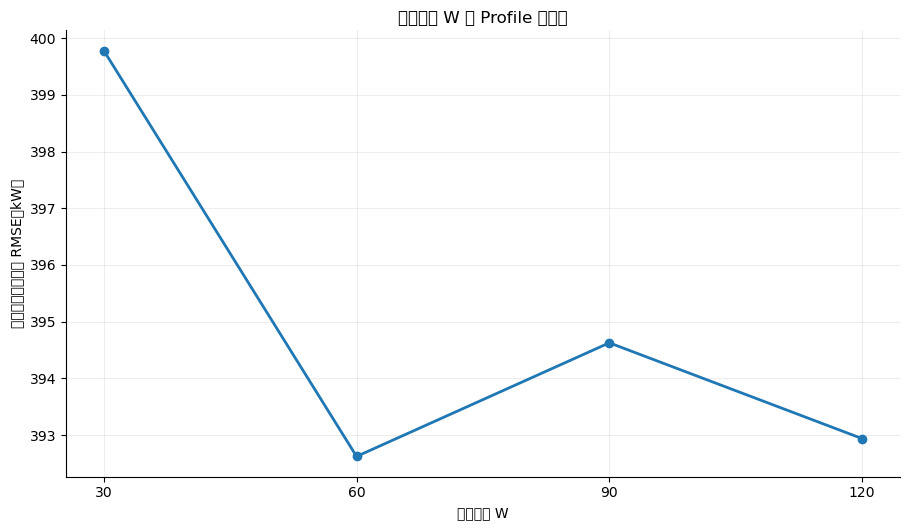

In [6]:
d = prof[prof["parameter"] == "W"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.2,5.4))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(d["fixed_value"].astype(str),
                   rotation=25 if "W" in ["hL","hP","calL","calP"] else 0,
                   ha="right" if "W" in ["hL","hP","calL","calP"] else "center")
ax.set_xlabel("历史窗口 W")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("历史窗口 W 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Load PCA维数 K_L

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
4,KL,1,416.1443,5.9908,30,1,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual2,0.1,30.0
5,KL,2,393.0214,0.1014,60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0
6,KL,3,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
7,KL,4,392.7215,0.0250,60,4,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,10.0
8,KL,5,392.9382,0.0802,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0


C:\Users\HP\AppData\Local\Temp\ipykernel_11608\3006069646.py:17: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\3006069646.py:17: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\3006069646.py:17: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\3006069646.py:17: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\3006069646.py:17: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\3006069646.py:17: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEO

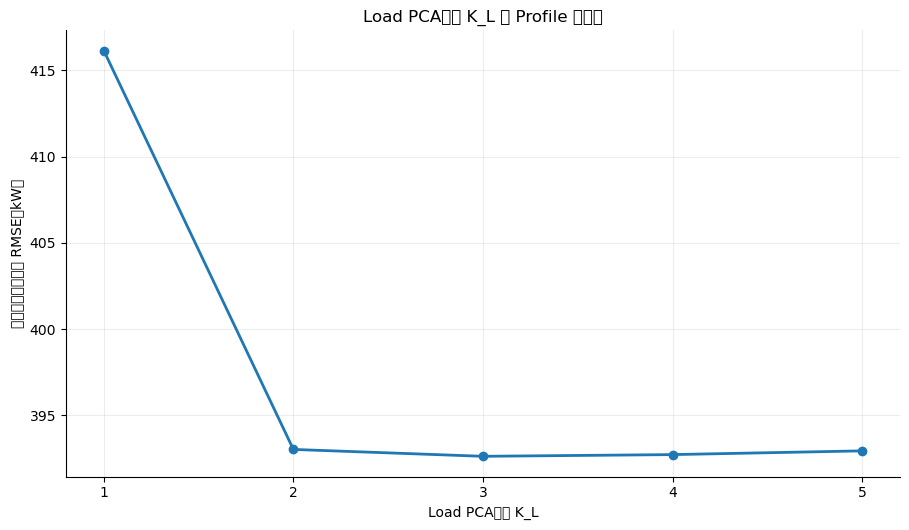

In [7]:
d = prof[prof["parameter"] == "KL"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.2,5.4))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(d["fixed_value"].astype(str),
                   rotation=25 if "KL" in ["hL","hP","calL","calP"] else 0,
                   ha="right" if "KL" in ["hL","hP","calL","calP"] else "center")
ax.set_xlabel("Load PCA维数 K_L")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("Load PCA维数 K_L 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## PV PCA维数 K_P

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
9,KP,1,401.1565,2.1734,60,3,1,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,1.0,3.0
10,KP,2,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
11,KP,3,395.9150,0.8384,120,5,3,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
12,KP,4,392.9382,0.0802,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0


C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1602303834.py:17: UserWarning: Glyph 32500 (\N{CJK UNIFIED IDEOGRAPH-7EF4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1602303834.py:17: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1602303834.py:17: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1602303834.py:17: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1602303834.py:17: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1602303834.py:17: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEO

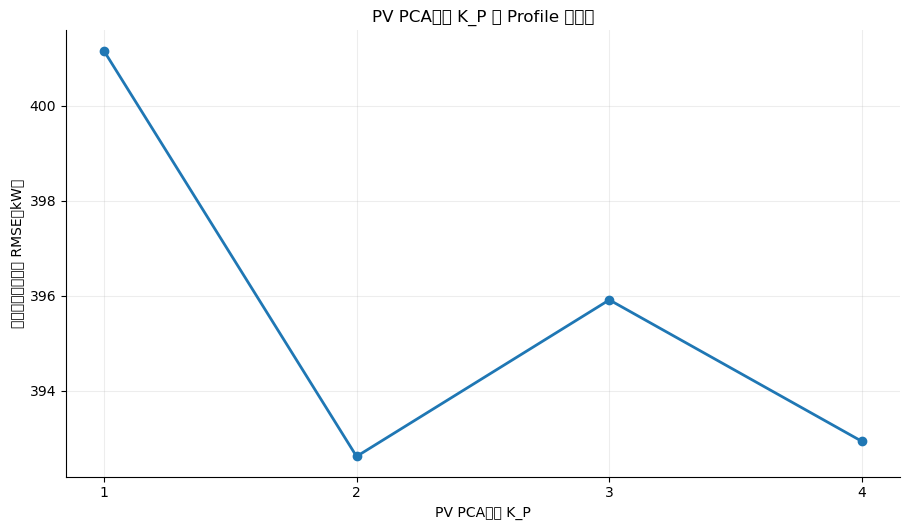

In [8]:
d = prof[prof["parameter"] == "KP"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.2,5.4))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(d["fixed_value"].astype(str),
                   rotation=25 if "KP" in ["hL","hP","calL","calP"] else 0,
                   ha="right" if "KP" in ["hL","hP","calL","calP"] else "center")
ax.set_xlabel("PV PCA维数 K_P")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("PV PCA维数 K_P 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Load历史状态

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
13,hL,H0_lag1,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
14,hL,H1_lag1_lag7,393.0214,0.1014,60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0
15,hL,H2_lag1_lag7_mean7,394.6270,0.5104,90,3,2,H2_lag1_lag7_mean7,H2_lag1_lag7_mean7,fri_sat,annual2,3.0,10.0
16,hL,H3_lag1_lag7_mean7_trend7,394.9553,0.5940,90,3,2,H3_lag1_lag7_mean7_trend7,H2_lag1_lag7_mean7,weekday7,annual2,0.1,10.0


C:\Users\HP\AppData\Local\Temp\ipykernel_11608\2047335359.py:17: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\2047335359.py:17: UserWarning: Glyph 21490 (\N{CJK UNIFIED IDEOGRAPH-53F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\2047335359.py:17: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\2047335359.py:17: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\2047335359.py:17: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\2047335359.py:17: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEO

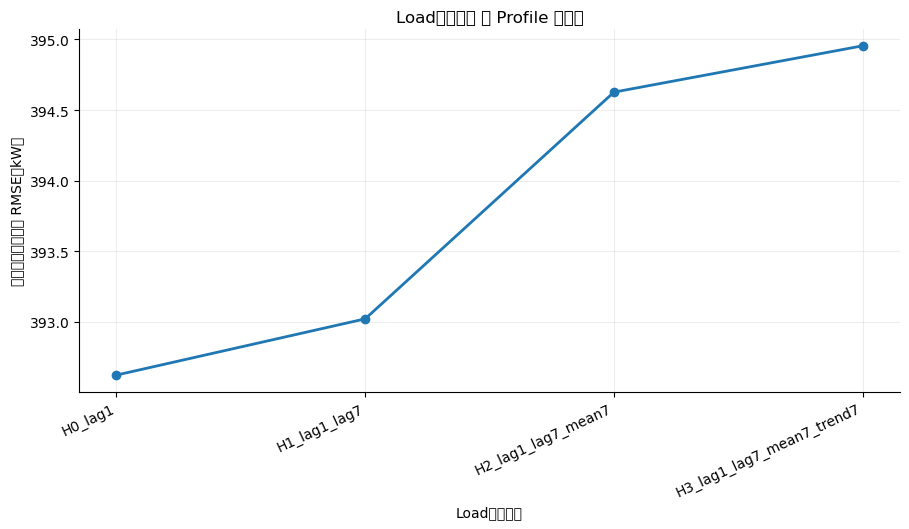

In [9]:
d = prof[prof["parameter"] == "hL"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.2,5.4))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(d["fixed_value"].astype(str),
                   rotation=25 if "hL" in ["hL","hP","calL","calP"] else 0,
                   ha="right" if "hL" in ["hL","hP","calL","calP"] else "center")
ax.set_xlabel("Load历史状态")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("Load历史状态 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## PV历史状态

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
17,hP,H0_lag1,392.9382,0.0802,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
18,hP,H1_lag1_lag7,397.4976,1.2415,120,5,2,H0_lag1,H1_lag1_lag7,weekday7,annual2,0.1,1.0
19,hP,H2_lag1_lag7_mean7,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
20,hP,H3_lag1_lag7_mean7_trend7,393.7317,0.2823,60,3,2,H0_lag1,H3_lag1_lag7_mean7_trend7,weekday7,annual1,0.3,3.0


C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1545578453.py:17: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1545578453.py:17: UserWarning: Glyph 21490 (\N{CJK UNIFIED IDEOGRAPH-53F2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1545578453.py:17: UserWarning: Glyph 29366 (\N{CJK UNIFIED IDEOGRAPH-72B6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1545578453.py:17: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1545578453.py:17: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1545578453.py:17: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEO

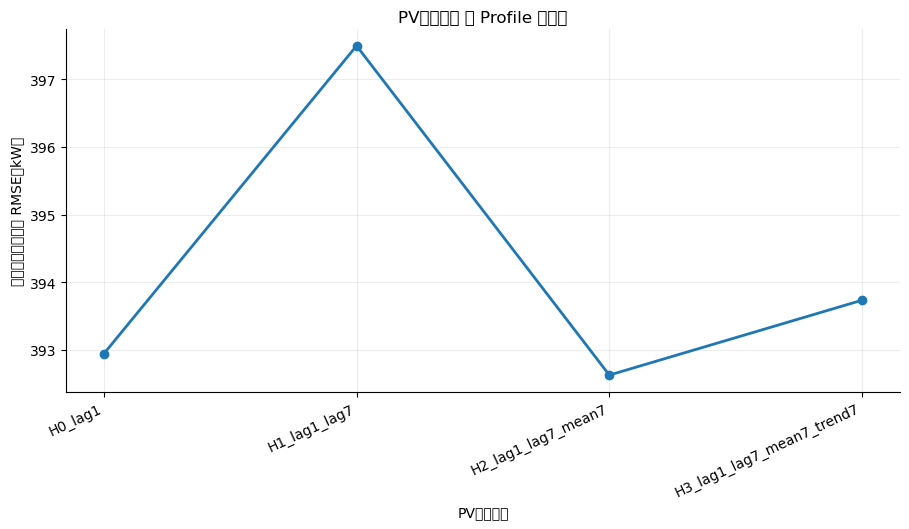

In [10]:
d = prof[prof["parameter"] == "hP"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.2,5.4))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(d["fixed_value"].astype(str),
                   rotation=25 if "hP" in ["hL","hP","calL","calP"] else 0,
                   ha="right" if "hP" in ["hL","hP","calL","calP"] else "center")
ax.set_xlabel("PV历史状态")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("PV历史状态 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Load日历特征

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
21,calL,fri_sat,393.0214,0.1014,60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0
22,calL,weekday7,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
23,calL,fri_sat+annual1,394.0928,0.3743,60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual1,annual1,1.0,10.0
24,calL,fri_sat+annual2,393.9749,0.3443,60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,1.0,10.0


C:\Users\HP\AppData\Local\Temp\ipykernel_11608\38950808.py:17: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\38950808.py:17: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\38950808.py:17: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\38950808.py:17: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\38950808.py:17: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\38950808.py:17: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171})

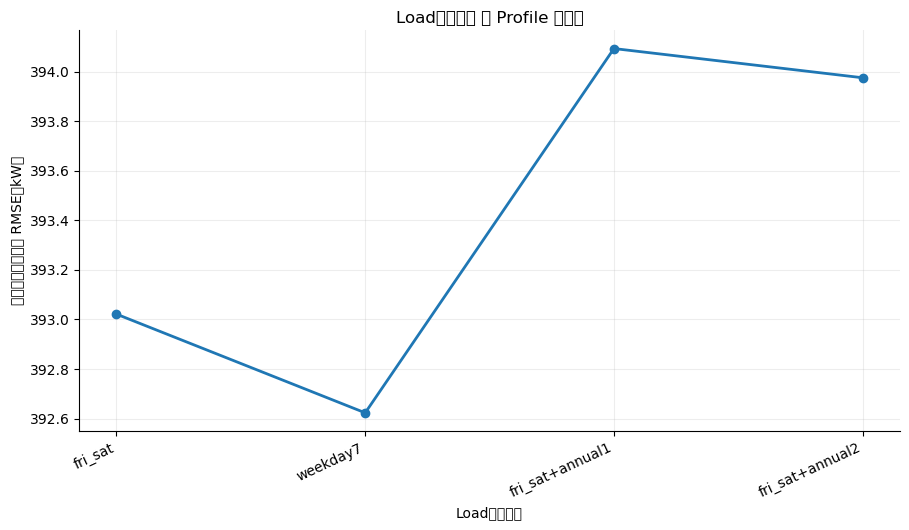

In [11]:
d = prof[prof["parameter"] == "calL"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.2,5.4))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(d["fixed_value"].astype(str),
                   rotation=25 if "calL" in ["hL","hP","calL","calP"] else 0,
                   ha="right" if "calL" in ["hL","hP","calL","calP"] else "center")
ax.set_xlabel("Load日历特征")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("Load日历特征 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## PV日历特征

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
25,calP,annual1,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
26,calP,annual2,392.9382,0.0802,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
27,calP,weekday7+annual1,398.2602,1.4357,120,5,4,H0_lag1,H2_lag1_lag7_mean7,weekday7,weekday7+annual1,0.1,30.0
28,calP,weekday7+annual2,397.4445,1.2280,120,5,4,H0_lag1,H2_lag1_lag7_mean7,weekday7,weekday7+annual2,0.1,30.0


C:\Users\HP\AppData\Local\Temp\ipykernel_11608\656546511.py:17: UserWarning: Glyph 26085 (\N{CJK UNIFIED IDEOGRAPH-65E5}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\656546511.py:17: UserWarning: Glyph 21382 (\N{CJK UNIFIED IDEOGRAPH-5386}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\656546511.py:17: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\656546511.py:17: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\656546511.py:17: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\656546511.py:17: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-

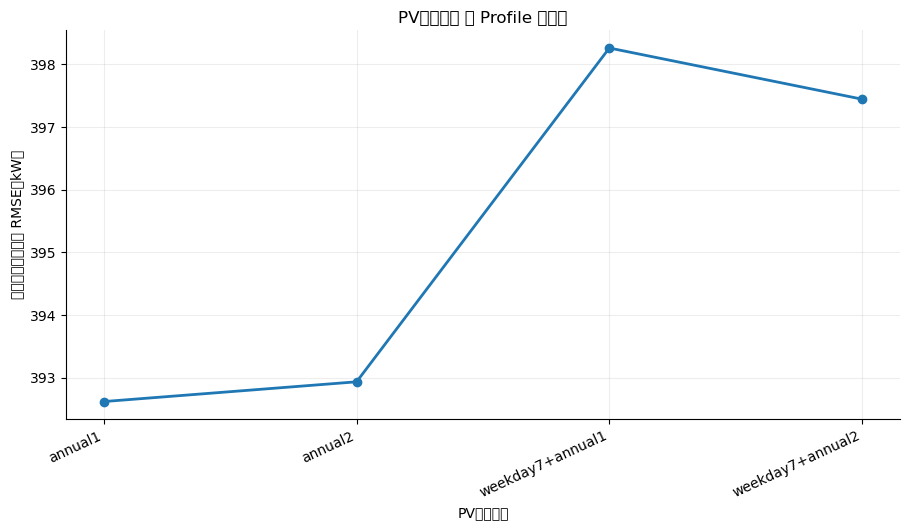

In [12]:
d = prof[prof["parameter"] == "calP"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.2,5.4))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(d["fixed_value"].astype(str),
                   rotation=25 if "calP" in ["hL","hP","calL","calP"] else 0,
                   ha="right" if "calP" in ["hL","hP","calL","calP"] else "center")
ax.set_xlabel("PV日历特征")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("PV日历特征 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Load Ridge α_L

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
29,alphaL,0.1,392.7215,0.0250,60,4,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,10.0
30,alphaL,0.3,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
31,alphaL,1.0,393.3500,0.1851,60,3,2,H0_lag1,H2_lag1_lag7_mean7,fri_sat,annual1,1.0,10.0
32,alphaL,3.0,394.2746,0.4206,60,3,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat+annual2,annual1,3.0,3.0
33,alphaL,10.0,396.6417,1.0235,120,4,4,H1_lag1_lag7,H0_lag1,fri_sat,annual2,10.0,3.0
34,alphaL,30.0,403.6769,2.8153,120,4,4,H2_lag1_lag7_mean7,H0_lag1,fri_sat,annual2,30.0,3.0
35,alphaL,100.0,435.4960,10.9196,120,4,4,H3_lag1_lag7_mean7_trend7,H2_lag1_lag7_mean7,fri_sat+annual1,annual1,100.0,30.0


C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1956221979.py:17: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1956221979.py:17: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1956221979.py:17: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1956221979.py:17: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1956221979.py:17: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\1956221979.py:17: UserWarning: Glyph 20928 (\N{CJK UNIFIED IDEO

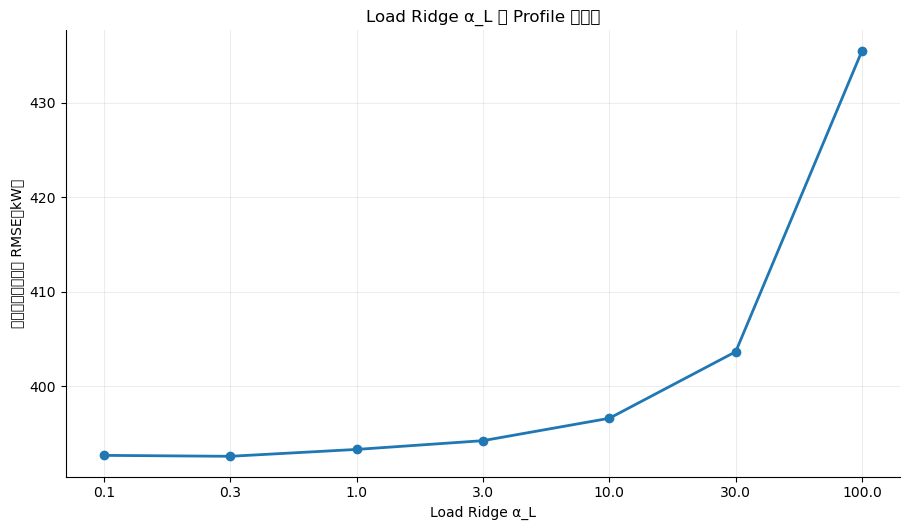

In [13]:
d = prof[prof["parameter"] == "alphaL"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.2,5.4))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(d["fixed_value"].astype(str),
                   rotation=25 if "alphaL" in ["hL","hP","calL","calP"] else 0,
                   ha="right" if "alphaL" in ["hL","hP","calL","calP"] else "center")
ax.set_xlabel("Load Ridge α_L")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("Load Ridge α_L 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## PV Ridge α_P

,parameter,fixed_value,rmse,increase_pct,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP
36,alphaP,0.1,398.4054,1.4727,120,5,2,H0_lag1,H0_lag1,weekday7,annual2,0.1,0.1
37,alphaP,0.3,395.3215,0.6872,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,0.3
38,alphaP,1.0,392.9382,0.0802,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0
39,alphaP,3.0,392.7362,0.0288,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,3.0
40,alphaP,10.0,392.6232,0.0000,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0
41,alphaP,30.0,395.1183,0.6355,120,5,4,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual2,0.1,30.0
42,alphaP,100.0,398.8843,1.5947,120,5,4,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual2,0.1,100.0


C:\Users\HP\AppData\Local\Temp\ipykernel_11608\2987895556.py:17: UserWarning: Glyph 20844 (\N{CJK UNIFIED IDEOGRAPH-516C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\2987895556.py:17: UserWarning: Glyph 20849 (\N{CJK UNIFIED IDEOGRAPH-5171}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\2987895556.py:17: UserWarning: Glyph 39564 (\N{CJK UNIFIED IDEOGRAPH-9A8C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\2987895556.py:17: UserWarning: Glyph 35777 (\N{CJK UNIFIED IDEOGRAPH-8BC1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\2987895556.py:17: UserWarning: Glyph 21306 (\N{CJK UNIFIED IDEOGRAPH-533A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_11608\2987895556.py:17: UserWarning: Glyph 20928 (\N{CJK UNIFIED IDEO

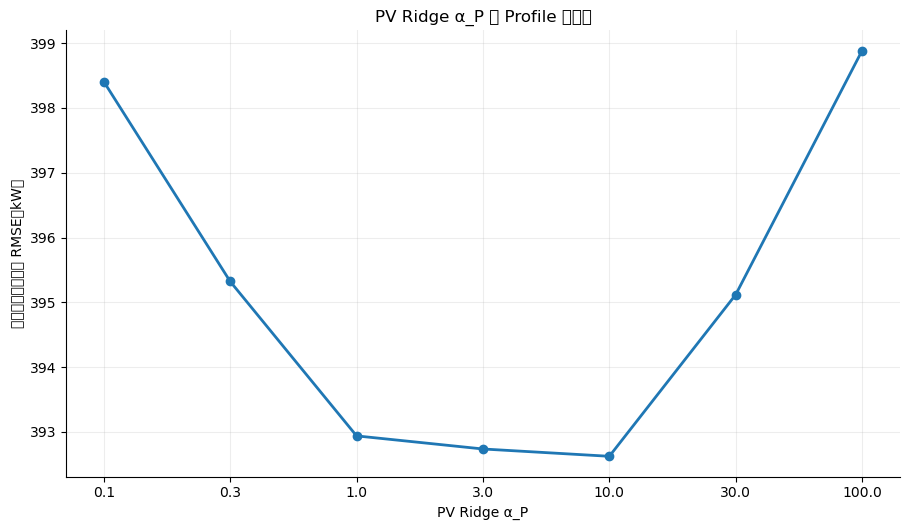

In [14]:
d = prof[prof["parameter"] == "alphaP"].copy()
display(d.round(4))

x = np.arange(len(d))
fig, ax = plt.subplots(figsize=(9.2,5.4))
ax.plot(x, d["rmse"], marker="o", linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(d["fixed_value"].astype(str),
                   rotation=25 if "alphaP" in ["hL","hP","calL","calP"] else 0,
                   ha="right" if "alphaP" in ["hL","hP","calL","calP"] else "center")
ax.set_xlabel("PV Ridge α_P")
ax.set_ylabel("公共验证区净负荷 RMSE（kW）")
ax.set_title("PV Ridge α_P 的 Profile 稳定性")
ax.grid(alpha=.22)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Top 20 联合配置

如果很多 Top 配置的 RMSE 很接近，但参数组合不同，说明不存在非常尖锐的唯一最优点，模型具有超参数可替代性。


In [15]:
display(top.head(20).round(4))

,W,KL,KP,hL,hP,calL,calP,alphaL,alphaP,val_net_rmse,load_id,pv_id
0,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0,392.6232,232,172
1,60,4,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,10.0,392.7215,343,172
2,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,3.0,392.7362,232,171
3,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,10.0,392.7499,231,172
4,60,3,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,3.0,392.8123,231,171
5,60,4,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.3,10.0,392.8950,344,172
6,120,5,4,H0_lag1,H0_lag1,weekday7,annual2,0.1,1.0,392.9382,455,345
7,60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.1,10.0,393.0214,140,172
8,60,2,2,H1_lag1_lag7,H2_lag1_lag7_mean7,fri_sat,annual1,0.3,10.0,393.1508,141,172
9,60,4,2,H0_lag1,H2_lag1_lag7_mean7,weekday7,annual1,0.1,3.0,393.2041,343,171


## 当前结论

公共验证区全局最优为：

- W = 60
- K_L = 3
- K_P = 2
- Load history = lag1
- PV history = lag1 + lag7 + mean7
- Load calendar = weekday7
- PV calendar = annual1
- α_L = 0.3
- α_P = 10

但 W=120 的最佳组合仅比 W=60 高约 0.08% RMSE，而且对应参数结构明显不同。

因此当前最准确的结论不是“只有这一组参数才对”，而是：

> 预测性能总体稳定，60–120 天存在性能平台；若某些超参数发生变化，其他参数可以部分补偿。当前 W=60 组合是验证区数值最优，但超参数结构存在一定可替代性。
